# Exploratory Data Analysis - EDA

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Paths
IMG_DIR = "../data/raw/images_training_rev1/images_training_rev1"
LABELS_PATH = "../data/raw/training_solutions_rev1/training_solutions_rev1.csv"

## Loading Dataset

In [2]:
labels_df = pd.read_csv(LABELS_PATH)
print(labels_df.shape)
labels_df.head()

(61578, 38)


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


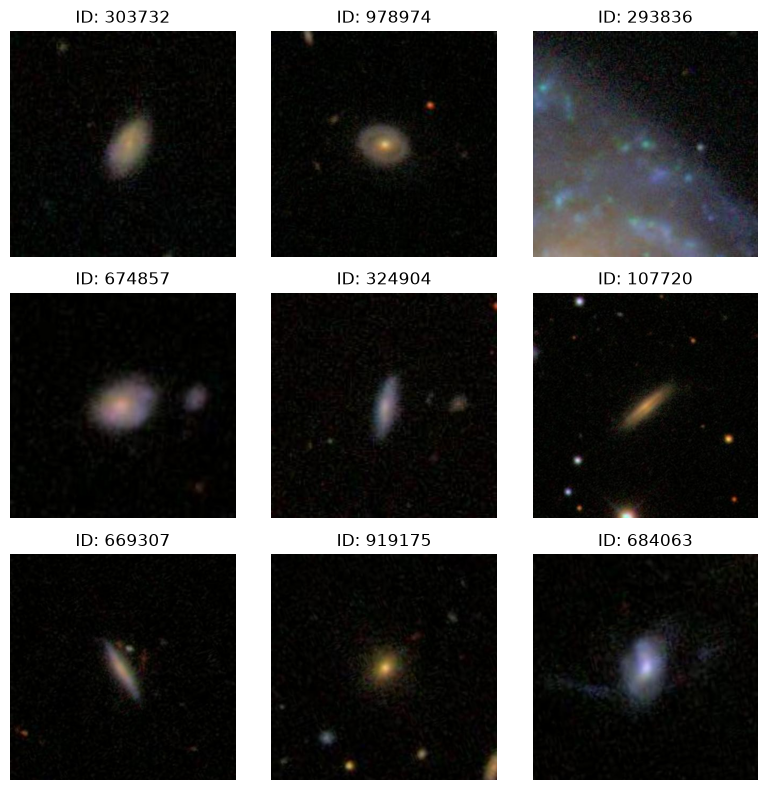

In [5]:
sample_ids = labels_df['GalaxyID'].sample(9, random_state=0).values

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, gid in zip(axes.flatten(), sample_ids):
    img_path = os.path.join(IMG_DIR, f"{gid}.jpg")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"ID: {gid}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Information To Know:

### The Labels in this Dataset

The labels in this dataset come from answers given by volunteers who were asked visual (YES/NO-ish) questions about each image, structured like a decision tree. The answer to one question determined what the next follow-up question would be.

Many volunteers looked at the same image and answered differently, so each column in the dataset isn't a clear yes or no — it's the fraction of volunteers who gave that answer. Ex: Class1.1 = 0.85, that is, 85% of the volunteers said the galaxy in the image looked smooth.

For this first version of the project, I'm using only the first two levels of the tree to keep things manageable:
- Class1.1 (smooth), Class1.2 (has features), Class1.3 (star/artifact — discarded as these aren't galaxies)
- Class4.1 (spiral pattern present), among galaxies that have features

This makes it so that there are only 3 broad classes — Smooth, Spiral, and Irregular.

### Galaxy Zoo 2 Full Decision Tree Reference

| Class | Question Asked | # Responses |
|---|---|---|
| **1** | Is the object smooth, has features/disk, or is it a star/artifact? | 3 |
| **2** | Is it edge-on? | 2 |
| **3** | Is there a bar? | 2 |
| **4** | Is there a spiral pattern? | 2 |
| **5** | How prominent is the central bulge? | 4 |
| **6** | Is there anything "odd" about the galaxy? | 2 |
| **7** | How round is the smooth galaxy? | 3 |
| **8** | What is the odd feature? | 7 |
| **9** | What shape is the bulge in the edge-on galaxy? | 3 |
| **10** | How tightly wound are the spiral arms? | 3 |
| **11** | How many spiral arms are there? | 6 |

**Used in this version (v1):** Class1, Class4
**Planned for a future version (v2):** Class7, Class2

## Class Distribution - Checking Imbalance

In [ ]:
clean_df = labels_df[labels_df['Class1.3'] < 0.5].copy()

def assign_class(row):
    if row['Class1.1'] >= 0.5:
        return 'Smooth'
    elif row['Class4.1'] >= 0.5:
        return 'Spiral'
    else:
        return 'Irregular'

clean_df['label'] = clean_df.apply(assign_class, axis=1)
print(clean_df['label'].value_counts())

label
Smooth       25868
Irregular    25269
Spiral       10397
Name: count, dtype: int64


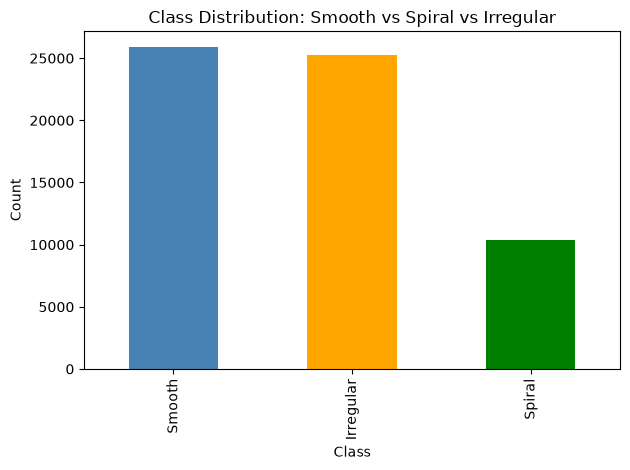

In [7]:
clean_df['label'].value_counts().plot(kind='bar', color=['steelblue', 'orange', 'green'])
plt.title('Class Distribution: Smooth vs Spiral vs Irregular')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png')
plt.show()